## Notebook 2 — Accept–Reject Sampling (implemented from scratch)
### Project: *Rare-Event Estimation in Water-Quality Control*

The dataset only gives us a few thousand observations. To run large simulations we need to
**generate** new samples from the fitted model $f(x)$. The project forbids built-in direct
samplers (e.g. `scipy.stats.norm.rvs`), so here we implement the **Accept–Reject** algorithm
ourselves, using only the uniform random primitive.

**The algorithm.** To sample from a target density $f$ using a simpler *proposal* density
$g$ for which sampling is easy, find a constant $M$ with
$$f(x) \le M\,g(x)\quad\text{for all }x.$$
Then repeat:
1. draw $Y \sim g$;
2. draw $U \sim \mathrm{Uniform}(0,1)$;
3. **accept** $Y$ if $U \le \dfrac{f(Y)}{M\,g(Y)}$, otherwise reject and retry.

Accepted values are exact draws from $f$. The **acceptance probability** equals $1/M$, so a
proposal close to the target (small $M$) is efficient, while a loose envelope (large $M$)
wastes work — this is **Analytical Question 1**, which we answer experimentally at the end.



In [1]:
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

SEED = 42
rng = np.random.default_rng(SEED)


def find_project_root() -> Path:
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "data" / "water_potability.csv").exists():
            return cand
    if here.name == "notebooks":
        return here.parent
    return here


ROOT = find_project_root()
DATA_PATH = ROOT / "data" / "water_potability.csv"
RESULTS = ROOT / "results"
RESULTS.mkdir(parents=True, exist_ok=True)

### Load the fitted model from Notebook 1

In [2]:
pfile = RESULTS / "fitted_params.json"
if pfile.exists():
    params = json.load(open(pfile))
    print("Loaded model from results/fitted_params.json")
else:
    print("fitted_params.json not found -> re-fitting from the CSV (run Notebook 1 first "
          "to persist the model).")
    _df = pd.read_csv(DATA_PATH)
    _x = _df["Chloramines"].dropna().to_numpy()
    _mu, _sig = stats.norm.fit(_x)
    _tau = float(stats.norm.ppf(1 - 1e-4, _mu, _sig))
    params = {
        "target": "Chloramines", "best_model": "Normal", "scipy_dist": "norm",
        "params": [float(_mu), float(_sig)], "mu": float(_mu), "sigma": float(_sig),
        "tau": _tau, "gamma_true": float(stats.norm.sf(_tau, _mu, _sig)),
        "target_prob": 1e-4, "data_max": float(_x.max()),
    }

# Unpack the working model f(x): the fitted Normal N(mu, sigma)
DIST = getattr(stats, params["scipy_dist"])
PARAMS = tuple(params["params"])
mu, sigma = params["mu"], params["sigma"]
tau = params["tau"]
gamma_true = params["gamma_true"]


def f_pdf(z):
    """Target density f(x) = fitted N(mu, sigma)."""
    return DIST.pdf(z, *PARAMS)


print(f"Working model f(x): {params['best_model']}  mu={mu:.4f}  sigma={sigma:.4f}")
print(f"Threshold tau     : {tau:.4f}")
print(f"True probability  : gamma = P(X>tau) = {gamma_true:.3e}")

Loaded model from results/fitted_params.json
Working model f(x): Normal  mu=7.1223  sigma=1.5831
Threshold tau     : 13.0089
True probability  : gamma = P(X>tau) = 1.000e-04


### Manual samplers (uniform primitive only)

In [3]:
def box_muller(size, loc=0.0, scale=1.0, rng=rng):
    """Generate Normal samples from Uniform(0,1) numbers via the Box-Muller transform.

    This is OUR OWN normal generator: it uses only the uniform primitive, never
    scipy's .rvs() or np.random.normal. It is the manual sampler used for the large
    Monte-Carlo / Importance-Sampling loops.
    """
    m = (size + 1) // 2
    u1 = rng.random(m)
    u2 = rng.random(m)
    r = np.sqrt(-2.0 * np.log(u1))
    theta = 2.0 * np.pi * u2
    z = np.empty(2 * m)
    z[0::2] = r * np.cos(theta)
    z[1::2] = r * np.sin(theta)
    return loc + scale * z[:size]


def accept_reject(size, target_pdf, a, b, M=None, rng=rng, return_stats=False):
    """Draw `size` samples from `target_pdf` on [a, b] using a Uniform(a,b) proposal g.

    Condition used:  target_pdf(x) <= M * g(x)  with g(x) = 1/(b-a).
    If M is None it is estimated as (b-a) * max_x target_pdf(x) on a fine grid.
    Only the uniform primitive is used; the accept/reject loop is implemented by hand.
    """
    if M is None:
        gx = np.linspace(a, b, 20000)
        M = (b - a) * np.max(target_pdf(gx)) * 1.001  # small safety margin
    g = 1.0 / (b - a)
    out = np.empty(size)
    filled = 0
    n_proposed = 0
    while filled < size:
        batch = max(size - filled, 1000)
        Y = rng.uniform(a, b, batch)         # proposal draw  Y ~ g
        U = rng.random(batch)                # U ~ Uniform(0,1)
        accept = U <= target_pdf(Y) / (M * g)
        Ya = Y[accept]
        take = min(len(Ya), size - filled)
        out[filled:filled + take] = Ya[:take]
        filled += take
        n_proposed += batch
    if return_stats:
        return out, dict(M=M, n_proposed=n_proposed,
                         empirical_acc=size / n_proposed,
                         theoretical_acc=1.0 / M)
    return out

## 1. Choosing the proposal \(g\) and the constant \(M\)

We use a **Uniform proposal** on a wide interval \([a,b]\) that covers essentially all of the
mass of \(f\). For a uniform proposal \(g(x)=\frac{1}{b-a}\), the envelope condition
\(f(x)\le M\,g(x)\) becomes
\[ M \;=\; (b-a)\,\max_x f(x). \]
We take \([a,b]=[0,\ \mu+6\sigma]\): the lower bound 0 is the physical floor for a
concentration, and \(\mu+6\sigma\) leaves \(<10^{-8}\) probability in the upper tail, so the
truncation is negligible.

In [4]:
a, b = 0.0, mu + 6 * sigma
fmax = np.max(f_pdf(np.linspace(a, b, 20000)))
M = (b - a) * fmax
print(f"Proposal interval [a, b] = [{a:.2f}, {b:.2f}]")
print(f"max f(x)                 = {fmax:.4f}")
print(f"Envelope constant M      = {M:.4f}")
print(f"Theoretical acceptance   = 1/M = {1/M:.4f}")

Proposal interval [a, b] = [0.00, 16.62]
max f(x)                 = 0.2520
Envelope constant M      = 4.1891
Theoretical acceptance   = 1/M = 0.2387


## 2. Generating samples and measuring the acceptance rate

In [5]:
N_AR = 100_000
t0 = time.perf_counter()
ar_samples, info = accept_reject(N_AR, f_pdf, a, b, M=M, rng=rng, return_stats=True)
elapsed = time.perf_counter() - t0

print(f"Generated {N_AR:,} samples in {elapsed:.3f} s")
print(f"Proposals drawn      : {info['n_proposed']:,}")
print(f"Empirical acceptance : {info['empirical_acc']:.4f}")
print(f"Theoretical 1/M      : {info['theoretical_acc']:.4f}")
print(f"\nGenerated sample : mean={ar_samples.mean():.4f} (model {mu:.4f}), "
      f"std={ar_samples.std(ddof=1):.4f} (model {sigma:.4f})")

Generated 100,000 samples in 0.029 s
Proposals drawn      : 420,295
Empirical acceptance : 0.2379
Theoretical 1/M      : 0.2387

Generated sample : mean=7.1221 (model 7.1223), std=1.5839 (model 1.5831)


The empirical acceptance rate matches the theoretical \(1/M\), and the sample moments
match the model — a first confirmation that the sampler is correct.

## 3. Validation: generated data vs. real data vs. the true density

The key check required by the project: the histogram of the **Accept–Reject** samples should
match both the **real** Chloramines histogram and the fitted density \(f(x)\).

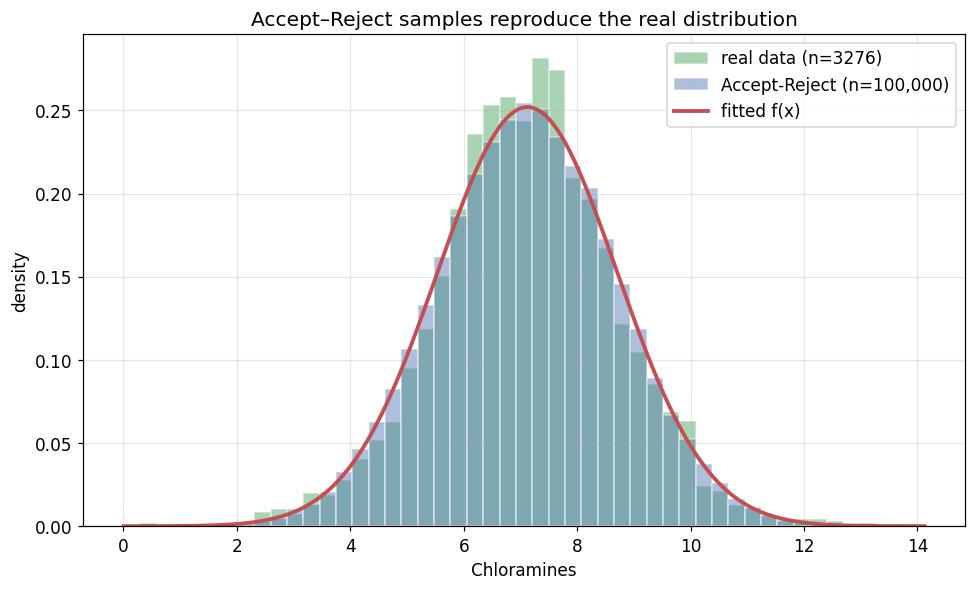

KS test (AR sample vs fitted f):  statistic=0.0017, p-value=0.932


In [6]:
real_x = pd.read_csv(DATA_PATH)["Chloramines"].dropna().to_numpy()

fig, ax = plt.subplots(figsize=(9, 5.5))
bins = np.linspace(a, real_x.max() + 1, 50)
ax.hist(real_x, bins=bins, density=True, alpha=0.5, color="#55A868",
        edgecolor="white", label=f"real data (n={len(real_x)})")
ax.hist(ar_samples, bins=bins, density=True, alpha=0.45, color="#4C72B0",
        edgecolor="white", label=f"Accept-Reject (n={N_AR:,})")
grid = np.linspace(a, real_x.max() + 1, 400)
ax.plot(grid, f_pdf(grid), color="#C44E52", lw=2.5, label="fitted f(x)")
ax.set_title("Accept–Reject samples reproduce the real distribution")
ax.set_xlabel("Chloramines"); ax.set_ylabel("density"); ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "02_accept_reject_histograms.png", bbox_inches="tight")
plt.show()

# Quantitative goodness-of-fit of the generated sample against f
ks = stats.kstest(ar_samples, params["scipy_dist"], args=PARAMS)
print(f"KS test (AR sample vs fitted f):  statistic={ks.statistic:.4f}, p-value={ks.pvalue:.3f}")

A large KS p-value means we cannot reject the hypothesis that the generated sample comes
from \(f\) — the sampler works.

## 4. Analytical Question 1 — acceptance rate, \(M\) and runtime

> *The more “dead space’’ the proposal has relative to the target (larger \(M\)), the lower the
> acceptance rate and the longer the runtime to generate a fixed number of samples.*

We test this directly by widening the proposal interval. A wider \([a,b]\) keeps the same
target but inflates \(M=(b-a)\max f\), so more proposals are wasted. We sweep the half-width
(in units of \(\sigma\)) and record both the acceptance rate and the time to draw a fixed
number of samples.

In [7]:
widths = [3, 4, 5, 6, 8, 10, 14, 20]   # half-width in units of sigma
N_fixed = 40_000
res = []
for w in widths:
    aa, bb = 0.0, mu + w * sigma
    Mw = (bb - aa) * np.max(f_pdf(np.linspace(aa, bb, 20000)))
    t0 = time.perf_counter()
    _, inf = accept_reject(N_fixed, f_pdf, aa, bb, M=Mw, rng=rng, return_stats=True)
    dt = time.perf_counter() - t0
    res.append([w, Mw, inf["empirical_acc"], 1 / Mw, inf["n_proposed"], dt])

q1 = pd.DataFrame(res, columns=["half_width_sigma", "M", "empirical_acc",
                                "theoretical_acc(1/M)", "proposals_drawn", "time_s"])
q1.round(4)

,half_width_sigma,M,empirical_acc,theoretical_acc(1/M),proposals_drawn,time_s
0,3,2.9921,0.3292,0.3342,121524,0.0039
1,4,3.3911,0.2928,0.2949,136614,0.0028
2,5,3.7901,0.2638,0.2638,151626,0.0033
3,6,4.1891,0.2377,0.2387,168289,0.0033
4,8,4.9871,0.2007,0.2005,199295,0.0040
5,10,5.7851,0.1733,0.1729,230808,0.0046
6,14,7.3812,0.1364,0.1355,293183,0.0057
7,20,9.7752,0.1018,0.1023,392841,0.0074


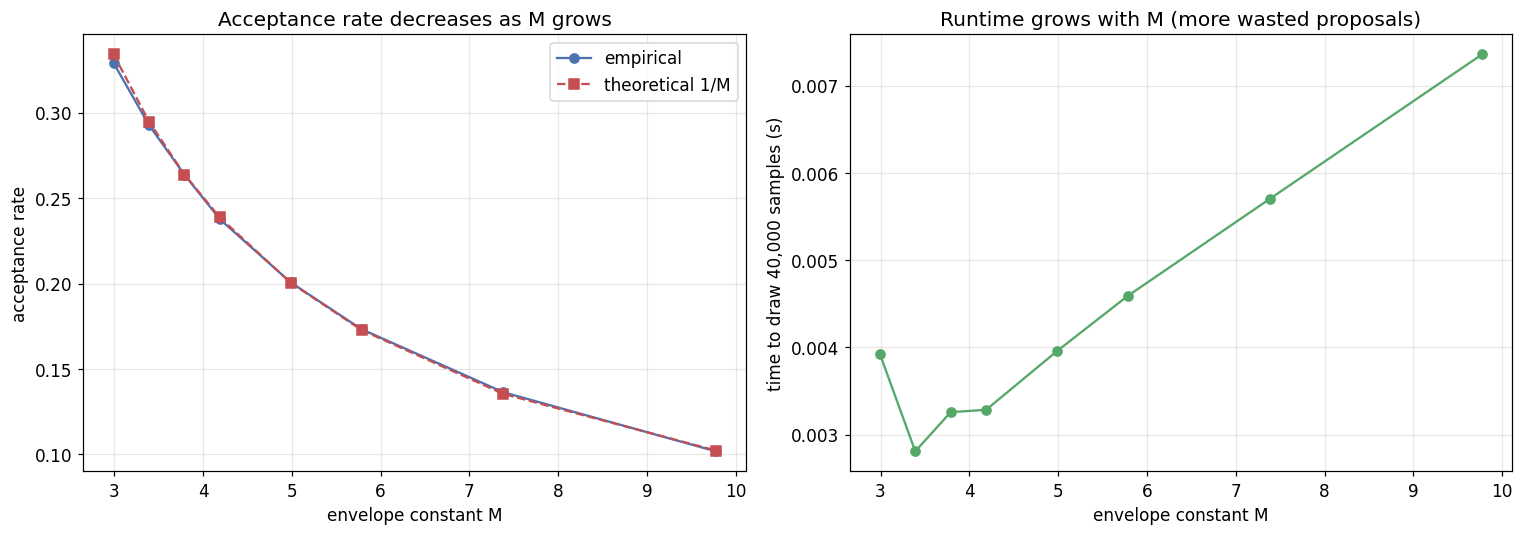

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(q1["M"], q1["empirical_acc"], "o-", color="#4C72B0", label="empirical")
axes[0].plot(q1["M"], q1["theoretical_acc(1/M)"], "s--", color="#C44E52", label="theoretical 1/M")
axes[0].set_xlabel("envelope constant M"); axes[0].set_ylabel("acceptance rate")
axes[0].set_title("Acceptance rate decreases as M grows"); axes[0].legend()

axes[1].plot(q1["M"], q1["time_s"], "o-", color="#55A868")
axes[1].set_xlabel("envelope constant M")
axes[1].set_ylabel(f"time to draw {N_fixed:,} samples (s)")
axes[1].set_title("Runtime grows with M (more wasted proposals)")
plt.tight_layout()
plt.savefig(RESULTS / "02_acceptance_vs_M.png", bbox_inches="tight")
plt.show()

**Answer to Q1.** The empirical acceptance rate tracks \(1/M\) almost exactly, and the
runtime for a fixed sample size grows roughly **linearly with \(M\)**: to obtain \(N\) accepted
samples we must draw on average \(N\cdot M\) proposals. Hence a proposal that hugs the target
(small \(M\), little dead space) is cheap, while a loose envelope (large \(M\)) is expensive.
The best practical advice is to choose \(g\) as close to \(f\) as possible and \(M\) as small as
the envelope condition allows.

In [9]:
np.save(RESULTS / "02_accept_reject_samples.npy", ar_samples)
q1.to_csv(RESULTS / "02_acceptance_vs_M.csv", index=False)
print("Saved AR samples and the Q1 table to results/.")

Saved AR samples and the Q1 table to results/.


### Summary

* Implemented Accept–Reject from scratch with a uniform proposal and \(M=(b-a)\max f\).
* Generated samples reproduce the real histogram and pass a KS test against \(f\).
* Confirmed experimentally that **acceptance \(=1/M\)** and that **runtime grows with \(M\)**.

➡️ **Next:** Notebook 3 uses sampling from \(f\) to estimate the rare-event probability
\(\gamma=P(X>\tau)\) with **standard Monte-Carlo**, and exposes why this is hard for rare
events.